# Predicting Online Purchase Intention from Web Session Behaviour

This notebook investigates whether e-commerce browsing sessions can be classified as purchase or non-purchase sessions using supervised machine learning.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42

## Initial data examination

In [3]:
df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


The first rows show that each record represents one online shopping session. The target variable is `Revenue`, which shows whether the session ended in a purchase.

The input features describe browsing behaviour, timing and visitor/session information. These include page counts, page durations, rates such as `BounceRates` and `ExitRates`, `PageValues`, `Month`, `VisitorType`, `Weekend` and coded technical features such as `Browser`, `Region` and `TrafficType`.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

The `df.info()` output shows that the dataset has 12,330 rows and 18 columns. All columns have 12,330 non-null values, so there are no missing values shown at this stage.

The data contains a mixture of integers, floats, strings and Boolean values. This means preprocessing will be needed before modelling, especially for categorical variables and Boolean values.

In [5]:
summary_checks = pd.DataFrame({
    "rows": [df.shape[0]],
    "columns": [df.shape[1]],
    "duplicate_rows": [df.duplicated().sum()],
    "missing_values_total": [df.isnull().sum().sum()]
})

summary_checks

,rows,columns,duplicate_rows,missing_values_total
0,12330,18,125,0


The dataset has 12,330 rows and 18 columns, with no missing values.

There are 125 duplicate rows. I will not remove them automatically because this is session data, and different sessions may have the same recorded behaviour.

In [6]:
revenue_summary = pd.DataFrame({
    "count": df["Revenue"].value_counts(),
    "percentage": df["Revenue"].value_counts(normalize=True) * 100
})

revenue_summary

,count,percentage
Revenue,,
False,10422,84.525547
True,1908,15.474453


The `Revenue` summary shows a clear class imbalance. Most sessions did not end in a purchase.

This matters because a model could get a decent accuracy by mostly predicting `False`. I will therefore use precision, recall, F1-score and a confusion matrix later, not just accuracy.

Next, I examine the numerical feature distributions to understand the scale and spread of the input variables.

In [7]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


The numerical columns have quite different ranges. For example, duration and page-count columns are much larger than rate columns such as `BounceRates` and `ExitRates`.

This means scaling may be useful later for models such as logistic regression or k-nearest neighbours. Tree-based models are less affected by scaling.

In [8]:
categorical_cols = ["Month", "VisitorType", "Weekend", "OperatingSystems", "Browser", "Region", "TrafficType"]

categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "most_common_value": df[categorical_cols].mode().iloc[0],
    "most_common_count": [df[col].value_counts().iloc[0] for col in categorical_cols]
})

categorical_summary

,unique_values,most_common_value,most_common_count
Month,10,May,3364
VisitorType,3,Returning_Visitor,10551
Weekend,2,False,9462
OperatingSystems,8,2,6601
Browser,13,2,7961
Region,9,1,4780
TrafficType,20,2,3913


This table shows the number of unique values in each categorical or coded feature.

These columns will need encoding before modelling, especially `Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region` and `TrafficType`.

In [9]:
df.groupby("Revenue")[["PageValues", "BounceRates", "ExitRates", "ProductRelated", "ProductRelated_Duration"]].mean()

,PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration
Revenue,,,,,
False,1.975998,0.025317,0.047378,28.714642,1069.987809
True,27.264518,0.005117,0.019555,48.210168,1876.209615


The grouped averages show clear differences between purchase and non-purchase sessions. Purchase sessions have much higher average `PageValues`, more `ProductRelated` page visits, longer `ProductRelated_Duration`, lower `BounceRates` and lower `ExitRates`.

This suggests that browsing depth and page value may be useful predictors. I will check this later using feature importance and model results.

## Exploratory visualisation

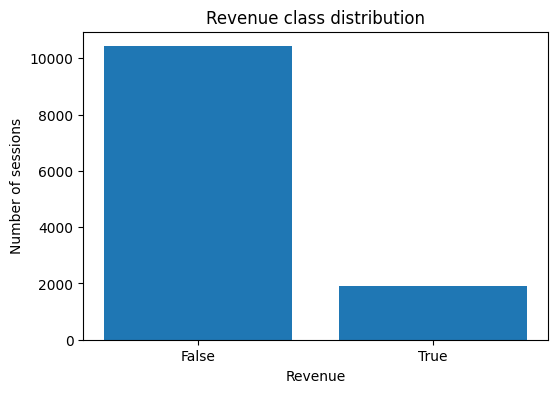

In [10]:
revenue_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(revenue_counts.index.astype(str), revenue_counts.values)
plt.title("Revenue class distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.show()

The chart shows a clear class imbalance. Most sessions did not end in a purchase.

Because of this, accuracy on its own will not be enough. I will also use precision, recall, F1-score and a confusion matrix later.

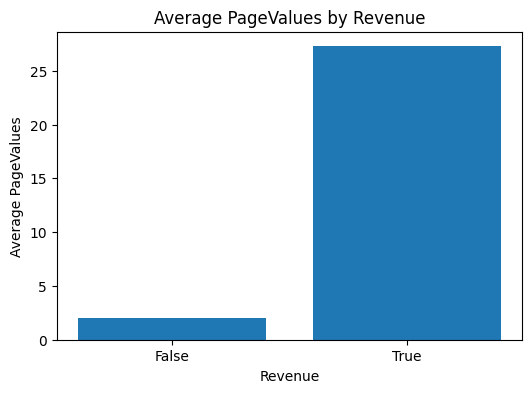

In [11]:
pagevalues_mean = df.groupby("Revenue")["PageValues"].mean()

plt.figure(figsize=(6, 4))
plt.bar(pagevalues_mean.index.astype(str), pagevalues_mean.values)
plt.title("Average PageValues by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average PageValues")
plt.show()

Purchase sessions have much higher average `PageValues`.

This suggests that `PageValues` may be useful for predicting `Revenue`. I will check this again later when comparing feature importance and model performance.

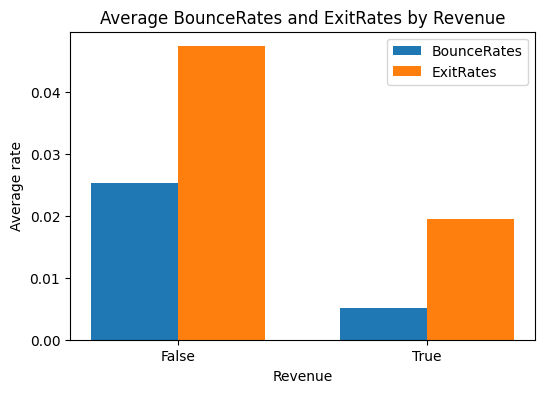

In [12]:
rate_means = df.groupby("Revenue")[["BounceRates", "ExitRates"]].mean()

x = np.arange(len(rate_means.index))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, rate_means["BounceRates"], width, label="BounceRates")
plt.bar(x + width/2, rate_means["ExitRates"], width, label="ExitRates")
plt.title("Average BounceRates and ExitRates by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Average rate")
plt.xticks(x, rate_means.index.astype(str))
plt.legend()
plt.show()

Purchase sessions have lower average `BounceRates` and `ExitRates`.

`BounceRates` refers to sessions where a user enters the site and leaves without continuing to other pages. `ExitRates` refers to how often users leave from a particular page. 

Lower values for purchase sessions suggest that users who stay and continue browsing are more likely to buy, so these features may help the models separate purchase and non-purchase sessions.

## Feature and target preparation

In [13]:
# Separate the input features from the target variable
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (12330, 17)
Target data shape: (12330,)


I split the dataset into `X` and `y`. `X` contains the input features, and `y` contains the target variable, `Revenue`.

This gives 17 features for each session and one target value to predict.

In [14]:
# Check the target balance before splitting the data
target_balance = pd.DataFrame({
    "count": y.value_counts(),
    "percentage": y.value_counts(normalize=True) * 100
})

target_balance

,count,percentage
Revenue,,
False,10422,84.525547
True,1908,15.474453


The target balance is checked again before splitting the data.

Because the classes are imbalanced, I will use a stratified train-test split so that the training and test sets keep a similar balance of purchase and non-purchase sessions.

In [ ]:
# Set up the column groups for preprocessing
categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features = [col for col in X.columns if col not in categorical_features]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


The columns are separated into categorical and numerical features.

The categorical list includes text columns, Boolean values and coded category columns. The remaining columns are treated as numerical browsing-behaviour features.

In [ ]:
# Split the data with an 80/20 train/test split
# Stratify keeps the Revenue balance similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (9864, 17)
Test features: (2466, 17)
Training target: (9864,)
Test target: (2466,)


The data is split into training and test sets. The training set will be used to fit the models, while the test set will be kept back for evaluation.

I used an 80/20 split because the dataset is large enough to leave a useful test set while still keeping most of the data for training.

In [21]:
# Check that the class balance is similar after the split
split_balance = pd.DataFrame({
    "train_percentage": y_train.value_counts(normalize=True) * 100,
    "test_percentage": y_test.value_counts(normalize=True) * 100
})

split_balance

,train_percentage,test_percentage
Revenue,,
False,84.529603,84.509327
True,15.470397,15.490673


`split_balance` confirms that stratification successfully maintained consistent class proportions between the training and testing sets.

In [ ]:
# Preprocessing setup
# Scale numbers and one-hot encode categories
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The preprocessor applies different steps to different column types.

The numerical columns are scaled with `StandardScaler`, and the categorical columns are converted with `OneHotEncoder`. This prepares the data for models that need numerical input.

## Candidate model choices

At this stage I want to try a few different classification models and see what happens, rather than deciding too early.

I am starting with logistic regression because it is one of the basic models and gives me a simple baseline. If this performs reasonably well, it would suggest that some of the patterns in the data are quite straightforward.

I also want to try a decision tree because it feels suitable for this dataset. The data has features like PageValues, ExitRates and ProductRelated duration, so it makes sense that a tree might be able to split the sessions into useful groups.

Random forest is worth trying because it is basically a stronger version of decision trees. It may perform better than one tree and it can also show feature importance, which will be useful later for the report.

I want to try k-nearest neighbours because it is a standard classification method from the labs, and it gives me another type of model to compare. Since it uses distances between rows, it also links back to why scaling the data matters.

Support vector machine is another standard classifier I want to test. I do not know yet whether it will be one of the best models here, but it is a useful comparison because it works differently from trees and logistic regression.

I have also looked into models that are often used for tabular data, so I want to try gradient boosting as well. I have not used it much before, but it may be good here because the earlier analysis showed differences between purchase and non-purchase sessions that may not be completely linear.

Finally, I want to try MLPClassifier as a simple neural network option. I am not going into more complex neural networks like LSTM because this dataset is not really a click-by-click sequence. Each row is already a summary of a session, so a normal classifier or a simple MLP seems more suitable.


## Baseline model comparison

I will now try several baseline classification models using the same train-test split and the same preprocessing steps.

Because the target is imbalanced, accuracy could be misleading. I will still record accuracy, but I will focus more on F1-score, recall, precision and the confusion matrix.

In [39]:
# Try a single decision tree next
# Balanced class weight gives more attention to the smaller purchase class
model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [40]:
y_pred = model_pipeline.predict(X_test)

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=True, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, pos_label=True, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, pos_label=True, zero_division=0))

Accuracy: 0.8491484184914841
Precision: 0.5132275132275133
Recall: 0.5078534031413613
F1-score: 0.5105263157894737


In [42]:
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion matrix:
[[1900  184]
 [ 188  194]]


In [43]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

       False       0.91      0.91      0.91      2084
        True       0.51      0.51      0.51       382

    accuracy                           0.85      2466
   macro avg       0.71      0.71      0.71      2466
weighted avg       0.85      0.85      0.85      2466



The first baseline model is logistic regression. It gives an accuracy of about 0.84, but accuracy is not the main focus because the target classes are imbalanced.

For the purchase class (`True`), the model has recall of 0.74, meaning it finds a good number of the actual purchase sessions. However, precision is lower at 0.49, meaning quite a few sessions predicted as purchases were actually non-purchases.

The confusion matrix shows this trade-off clearly. The model correctly identified 284 purchase sessions, but missed 98 purchase sessions and incorrectly predicted 294 non-purchase sessions as purchases. This gives a useful baseline, but it needs comparing with tree-based models to see whether they handle the patterns better.

Random forest gives higher accuracy than logistic regression, at about 0.89. It also has much higher precision for the purchase class, at 0.76, meaning that when it predicts a purchase it is more often correct.

However, its recall for the purchase class is lower, at 0.46. This means it misses more actual purchase sessions than logistic regression. The confusion matrix shows this clearly: it correctly identifies 176 purchase sessions, but misses 206.

So random forest gives fewer false purchase predictions, but it misses more real purchases than logistic regression.

The decision tree gives an accuracy of about 0.85. For the purchase class, precision and recall are both about 0.51, so it is more balanced than the previous two models but not especially strong.

The confusion matrix shows that it correctly identifies 194 purchase sessions and misses 188. It also predicts 184 non-purchase sessions as purchases.

Compared with random forest, the decision tree finds slightly more purchase sessions, but it also makes more false purchase predictions. This is expected because a single decision tree is usually less stable than a random forest.